```
OPEIST - Prva laboratorijska vježba 
Filip Sučić, ak. god. 25/26 
JMBAG: 0036540149
```

### Zadatak:
Obiteljsko poljoprivredno gospodarstvo Babina Njiva uzgaja pšenicu i kukuruz na svojoj farmi od 50 hektara. Može prodati najviše 140 tona pšenice i 120 tona kukuruza. Svaki hektar zasađen pšenicom daje 5 tona, a svaki hektar zasađen kukuruzom daje 4 tona. Pšenica se prodaje za 30 eura po toni, a kukuruz za 50 eura po toni. Za žetvu hektara pšenice potrebno je 6 sati rada, a za žetvu hektara kukuruza potrebno je 10 sati. Do 350 sati rada može se kupiti za 10 eura po satu. Odrediti optimalni plan proizvodnje.

### Rješenje:
Imamo varijable $x_{1}, x_{2}$ - hektari zasađeni pšenicom i kukuruzom.


Iz prve rečenice trivijalno slijedi prvi uvjet: \
$x_{1} + x_{2} = 50$

Iz druge i treće rečenice da se zaključiti: \
$5 * x_{1} <= 140$ i $4 * x_{2} <= 120$

Žetva jednog hektara pšenice = 6 sati rada i od tog jednog hektara dobije se 5 tona. Tih 5 tona proda se za 30 eur/tona => 150 eura. Na to treba se potrošiti 6 * 10 = 60 eura. Zarada je 90 eura po hektaru. Analogno za kukuruz zarada je 100 eura po hektaru. Iz toga slijedi da je ciljna funkcija:

$90 * x_{1} + 100 * x_{2}$

Posljednje uvjet dobije se iz činjenice da je za žetvu hektara pšenice i kukurza potrebno 6 i 10 sati te da se maksimalno kupuje 350 sati rada: \
$6 * x_{1} + 10 * x_{2} <= 350$.

In [1]:
# Numeričko rješenje primala...
from pulp import LpProblem, LpVariable, LpMaximize, value

problem = LpProblem("babina_njiva", LpMaximize)

x1 = LpVariable("psenica", lowBound=0)
x2 = LpVariable("kukuruz", lowBound=0)

problem += 90*x1 + 100*x2

problem += x1 + x2 <= 50
problem += 5*x1 <= 140
problem += 4*x2 <= 120
problem += 6*x1 + 10*x2 <= 350

problem.solve()

print("Optimalno rješenje:")
print(f"x1 = {x1.varValue}")
print(f"x2 = {x2.varValue}")
print(f"Ciljna funkcija: {value(problem.objective)}")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/filip/FER/.venv/lib/python3.8/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/1t/4_dh6rmj6l1394_g82n8lpj00000gn/T/74270a64ab7542eea561855e010a0da3-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/1t/4_dh6rmj6l1394_g82n8lpj00000gn/T/74270a64ab7542eea561855e010a0da3-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 9 COLUMNS
At line 18 RHS
At line 23 BOUNDS
At line 24 ENDATA
Problem MODEL has 4 rows, 2 columns and 6 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 2 (-2) rows, 2 (0) columns and 4 (-2) elements
0  Obj -0 Dual inf 190 (2)
1  Obj 4340
Optimal - objective value 4340
After Postsolve, objective 4340, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 4340 - 1 iterations time 0.002, Presolve 0.00
Option for printingOptions changed from n

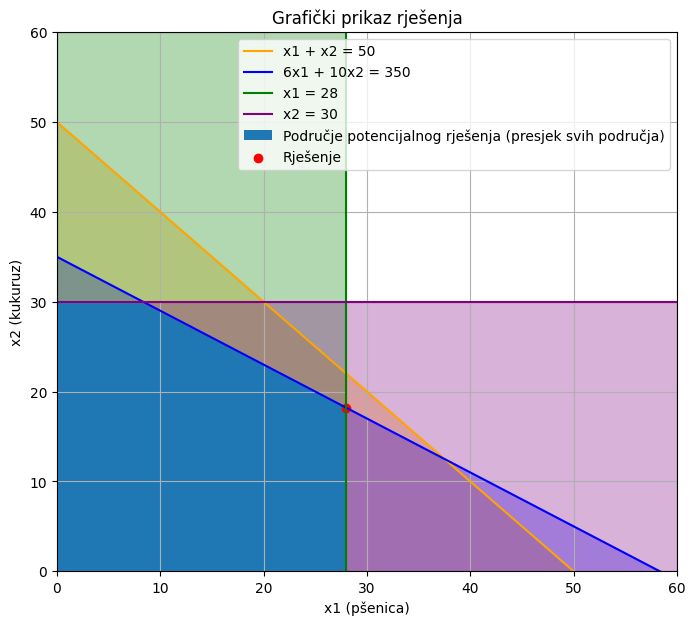

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 60, 400)
y = np.linspace(0, 60, 400)

plt.figure(figsize=(8,7))

y1 = 50 - x
y2 = (350 - 6*x)/10
x_v = 28
y_h = 30

plt.plot(x, y1, label="x1 + x2 = 50", color='orange')
plt.plot(x, y2, label="6x1 + 10x2 = 350", color='blue')
plt.axvline(x_v, label="x1 = 28", color='green')
plt.axhline(y_h, label="x2 = 30", color='purple')

plt.fill_between(x, 0, y1, color='orange', alpha=0.3)
plt.fill_between(x, 0, y2, color='blue', alpha=0.3)
plt.fill_betweenx(y, 0, x_v, color='green', alpha=0.3)
plt.fill_betweenx(y, 0, 60, where=y<=y_h, color='purple', alpha=0.3)

points = np.array([ [0,0], [0,30], [8,30], [28,18.2], [28,0] ]); plt.fill(points[:,0], points[:,1], label='Područje potencijalnog rješenja (presjek svih područja)')

plt.scatter([28], [18.2], color='red', label='Rješenje')

plt.xlim(0,60)
plt.ylim(0,60)
plt.xlabel("x1 (pšenica)")
plt.ylabel("x2 (kukuruz)")
plt.title("Grafički prikaz rješenja")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
from pulp import LpProblem, LpVariable, LpMinimize, value

dual = LpProblem("dual_babina_njiva", LpMinimize)

y1 = LpVariable("y1", lowBound=0)
y2 = LpVariable("y2", lowBound=0)
y3 = LpVariable("y3", lowBound=0)
y4 = LpVariable("y4", lowBound=0)

dual += 50*y1 + 140*y2 + 120*y3 + 350*y4

dual += 1*y1 + 5*y2 + 0*y3 + 6*y4 >= 90

dual += 1*y1 + 0*y2 + 4*y3 + 10*y4 >= 100

dual.solve()

print("Optimalno rješenje duala:")
print(f"y1 = {y1.varValue}")
print(f"y2 = {y2.varValue}")
print(f"y3 = {y3.varValue}")
print(f"y4 = {y4.varValue}")
print(f"Ciljna funkcija duala: {value(dual.objective)}")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/filip/FER/.venv/lib/python3.8/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/1t/4_dh6rmj6l1394_g82n8lpj00000gn/T/db5284411bc04a05b3e1504b620b530c-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/1t/4_dh6rmj6l1394_g82n8lpj00000gn/T/db5284411bc04a05b3e1504b620b530c-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 7 COLUMNS
At line 18 RHS
At line 21 BOUNDS
At line 22 ENDATA
Problem MODEL has 2 rows, 4 columns and 6 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 2 (0) rows, 4 (0) columns and 6 (0) elements
0  Obj 0 Primal inf 25 (2)
2  Obj 4340
Optimal - objective value 4340
Optimal objective 4340 - 2 iterations time 0.002
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.00   (Wallclock seconds):       0.01

Optimalno rje

Zemljište nije u potpunosti iskorišteno (28ha + 18.2ha = 46.2ha). Više zemljišta neće rezultirati većom zaradom ($y_{1}$ = 0).

Proizvodnja pšenice je maksimizirana ($5 \cdot x_{1} = 140$), svaka dodatna tona pšenice povećala bi zaradu za 6 eura ($y_{2} = 6$).

Proizvodnja kukuruza nije maksimizirana ($4 \cdot x_{2} < 120$), svaka dodatna tona pšenice ne bi rezultirala većom zaradom.

Dostupni sati su maksimizirani (350 sati iskorišteno). Svaki dodatni sat rada povećao bi zaradu za 10 eura ($y_{4} = 10$).


Zadatak nije bilo potrebno rješavati kao cjelobrojni problem linearnog programiranja jer je prihvatljivo da rješenje ne budu cijeli brojevi (s obzirom da se radi o hektarima zemlje).
